In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image, display

class State(TypedDict):
    data: str 
    counter: int

graph_builder = StateGraph(State)

def process_state(state: State) -> State:
    print(f"Current data: {state["data"]}, Counter: {state["counter"]}")
    return {"data": state["data"].upper(), "counter":state["counter"]+1}

graph_builder.add_node("process_state", process_state)
graph_builder.add_edge(START, "process_state")
graph_builder.add_edge("process_state", END)


graph = graph_builder.compile()

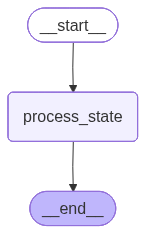

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
initial_state = {"data": "my input", "counter": 0}
result = graph.invoke(initial_state)

Current data: my input, Counter: 0


In [11]:
print(result)

{'data': 'MY INPUT', 'counter': 1}
